In [1]:
import pandas as pd
import numpy as np
import scipy as sp


import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from models import Filter_type, get_filter, get_MP
import stumpy as st

## Example

### Data generation

This section presents an example for stumpy usage, based on the Matrix Profile papers from Professor Eamon Keogh.

Each synthetic signal is composed of three components:

$$y_i = b_i + h_i + s_i$$

$b_i$ is a low frequency component

$h_i$ is a high frequency component

$s_i$ is a random noise added throughout the whole signal

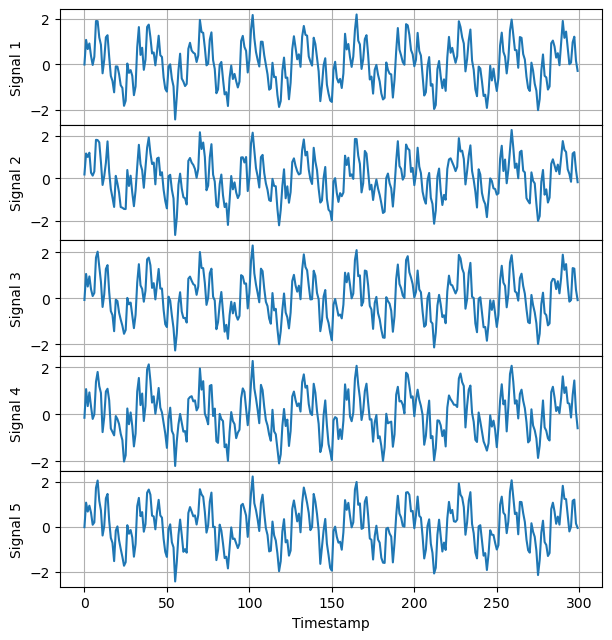

In [2]:
# Generating multi-dimensional time series
C = 5                                   # Dimension (number of signals)
N = 300                                 # Number of measurements
sigma = np.array([1, 2, 1, 2, 1])*0.1   # Standard deviation of noise from each signal


# Generating the components of the time series
ti = np.arange(N)
y0 = np.empty((C,N), dtype=float)
bi = np.empty((C,N), dtype=float)
hi = np.empty((C,N), dtype=float)
si = np.empty((C,N), dtype=float)



for i in range(C):
    bi[i,:] = np.sin(0.2*ti)
    si[i,:] = np.random.normal(0,sigma[i],N)
    hi[i,:] = 0.3*np.sin(2*ti) + 0.2*np.sin(5*ti) + 0.8*np.sin(1*ti) + 0.2*np.sin(9*ti)
    y0[i,:] = bi[i,:] + hi[i,:] + si[i,:]

# Plotting the figures
fig, axs = plt.subplots(C, sharex=True, gridspec_kw={'hspace': 0},figsize=[7,1.5*C])

# So it doesn't break if C == 1
if C == 1: 
    axs = [axs]  

# Plot figure
for i in range(C):
    axs[i].plot(ti,y0[i,:]);
    axs[i].set_ylabel(f'Signal {i+1}')
    axs[i].grid(True)

axs[i].set_xlabel('Timestamp');


### Noise insertion

After generating the "proper" data, we insert anomalies in it. This is done by including random noise at certain locations

[2 1] 4
[1 3 2] 4
[3] 4


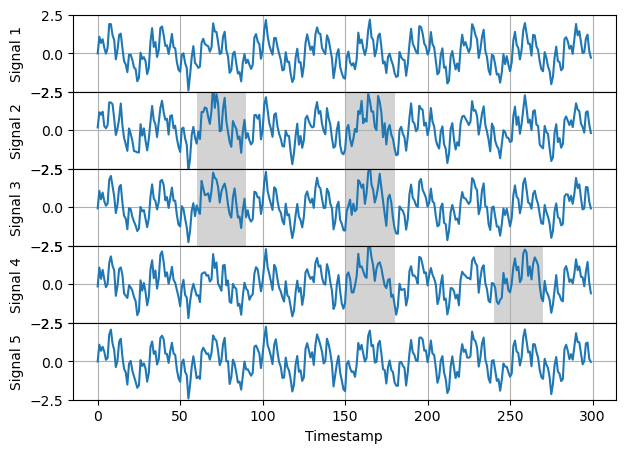

In [3]:
# Size of the anomalies
size = N//10 

# Anomaly location (# signals with anomaly, start, size)
anomalies = [(2,int(0.2*N),size,[]), 
             (3,int(0.5*N),size,[]),
             (1,int(0.8*N),size,[])]

y = y0.copy()


for o in range(len(anomalies)):

    # Getting information, choosing faulty signals and saving this info
    num_signals,start,size,_  = anomalies[o]
    series = np.random.default_rng().choice(C,size=num_signals,replace=False)
    anomalies[o][3].extend(series)
    print(series, i)

    for s in series:
        y[s,start:start+size] += 1*np.random.rand(size)

# Creating figure
fig, axs = plt.subplots(C, sharex=True, gridspec_kw={'hspace': 0},figsize=[7,1*C])

# So it doesn't break if C == 1
if C == 1: 
    axs = [axs]  

# Plot figure
max_y = 2.5
for i in range(C):
    axs[i].plot(ti,y[i,:]);
    axs[i].set_ylim([-max_y,max_y])
    axs[i].set_ylabel(f'Signal {i+1}')
    axs[i].grid(True)

for _,start,size,series in anomalies:
    for s in series:
        rect = Rectangle((start, -max_y), size, 2*max_y, facecolor='lightgrey')
        axs[s].add_patch(rect)

axs[i].set_xlabel('Timestamp');

### Filtering

Before applying the stumpy procedure, a filtering technique is used. Here, the Butterworth pass-band filter from scipy is used.

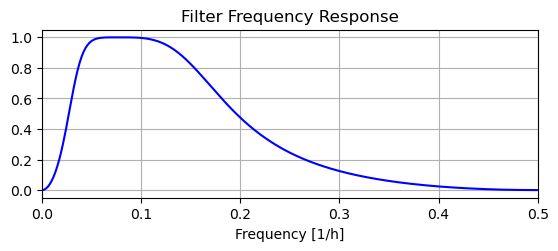

In [4]:
# Create filter
sampling = 1 # 1 measurement / hour
T_cutoff = np.array([30, 6]) # 6 hour cutoff period
filter_type = Filter_type.BUTTER_PASS
order = 2

cutoff_freq = 1/T_cutoff

num_coef, den_coef = get_filter(filter_type, sampling_freq=sampling, cutoff_freq=cutoff_freq, order=order)

w, h = sp.signal.freqz(num_coef, den_coef, fs=sampling)

plt.subplot(2, 1, 1)
plt.plot(w, np.abs(h), 'b')
plt.xlim(0, 0.5*sampling)
plt.title("Filter Frequency Response")
plt.xlabel('Frequency [1/h]')
plt.grid()


Then, we can apply the filter to the generated data

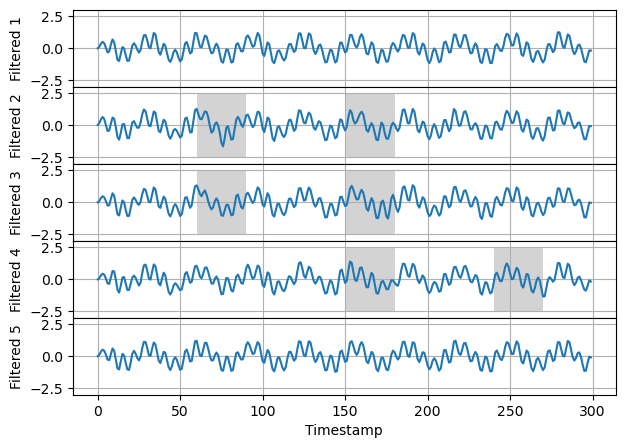

In [5]:
filtering_on = True

if filtering_on:

    # Creating figure
    fig, axs = plt.subplots(C, sharex=True, gridspec_kw={'hspace': 0},figsize=[7,1*C])

    # So it doesn't break if C == 1
    if C == 1: 
        axs = [axs]  


    y_filtered = np.empty_like(y)

    for i in range(C):
        y_filtered[i,:] = sp.signal.lfilter(num_coef,den_coef,y[i,:])
        axs[i].plot(ti,y_filtered[i,:]);
        axs[i].set_ylabel(f'Filtered {i+1}')
        axs[i].set_ylim([-3,3])
        axs[i].grid(True)

    axs[i].set_xlabel('Timestamp')

    for _,start,size,series in anomalies:
        for s in series:
            rect = Rectangle((start, -max_y), size, 2*max_y, facecolor='lightgrey')
            axs[s].add_patch(rect)
    
else:

    y_filtered = y.copy()
    

### Matrix Profile

Now that we have the filtered data, we can calculate the Matrix Profile

In [6]:
# Defining matrix profile subsequence size
sub_size = 40
MPs = np.empty((C,ti.size-sub_size+1), dtype=float)
quartile = 0.75


MP = get_MP(y_filtered, sub_size, quartile = quartile, ignore_start = True)

Text(0.5, 0, 'Timestamp')

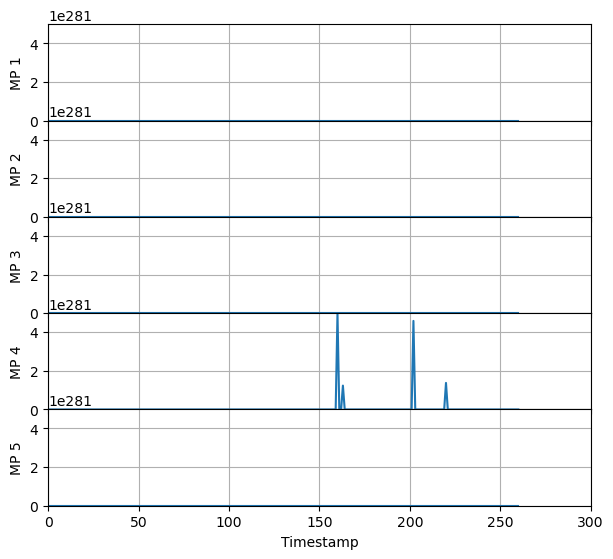

In [7]:
max_y = np.max(MPs)
fig, axs = plt.subplots(C, sharex=True, gridspec_kw={'hspace': 0},figsize=[7,1.25*C])
if C == 1:
    axs = [axs]
for k in range(C):
    axs[k].plot(MPs[k,:]);
    axs[k].set_ylim([0,max_y])
    axs[k].grid(True)
    axs[k].set_ylabel(f'MP {k+1}')
    axs[k].set_xlim([0,300])
axs[k].set_xlabel('Timestamp')